# Klara: checking the final comparison
Anas Mhana

Can attention fine-tuning improve the clothing match while keeping the person and background unchanged?

This notebook checks the training record and reproduces the final image measurements. It works from the saved files, so you don't need to download models, start a GPU or use a cloud account.

In [1]:
from pathlib import Path
import json, hashlib, sys, collections
import numpy as np
import pandas as pd
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'code'))
E = ROOT / 'evidence/final-test-1000-01'
T = ROOT / 'evidence/training-1000-01'
digest = lambda p: hashlib.sha256(p.read_bytes()).hexdigest()
run = json.loads((T/'run.json').read_text())
checkpoint = T/'attention-adapter.safetensors'
if checkpoint.is_file():
    assert digest(checkpoint) == run['adapter_sha256']
    print('Local checkpoint hash matches the training record.')
else:
    print('Checkpoint binary not bundled in Git. Local weight-file check skipped; see CHECKPOINT.md.')
assert run['steps_completed'] == 3000 and run['epochs'] == 3
assert run['frozen_weights_unchanged'] and run['adapter_reload_verified']
steps = [json.loads(line) for line in (T/'steps.jsonl').read_text().splitlines()]
for epoch in (1, 2, 3):
    ids = [row['training_case_id'] for row in steps if row['epoch'] == epoch]
    assert len(ids) == len(set(ids)) == 1000
print('Verified three complete epochs and the recorded frozen-weight/reload checks.')

Checkpoint binary not bundled in Git. Local weight-file check skipped; see CHECKPOINT.md.
Verified three complete epochs and the recorded frozen-weight/reload checks.


## What to know about the data
I made a custom training, validation and test split from the original VITON-HD test partition. The checks cover source IDs and exact image duplicates. They don't establish that different splits contain different people, or rule out exposure during the original model's training.

Each input is an edited version of an original photograph. That original is the reference target. The experiment measures how closely the output reconstructs it. It doesn't measure physical fit.

In [2]:
from analyze_final_1000 import analyze
from contextlib import redirect_stdout
import io
saved = json.loads((E/'analysis.json').read_text())
with redirect_stdout(io.StringIO()):
    recomputed = analyze(E, ROOT/'data/final-evaluation-plan.json', ROOT/'code/training-feasibility/evaluate_final_1000.py')
assert recomputed['summary'] == saved['summary']
assert recomputed['complete_cases'] == saved['complete_cases']
assert recomputed['images_verified'] == saved['images_verified']
print('All final image hashes and regional metrics reproduced.')

All final image hashes and regional metrics reproduced.


In [3]:
table = []
for metric, values in recomputed['summary'].items():
    effect = values['comparisons']['adapted-1000_vs_pretrained']
    table.append({'metric':metric, 'cases':values['n'],
        'pretrained':values['models']['pretrained']['mean'],
        'fine_tuned':values['models']['adapted-1000']['mean'],
        'mean_delta':effect['mean_delta_new_minus_old'],
        'improved':effect['wins'], 'worsened':effect['losses'],
        'descriptive_95_interval':effect['descriptive_paired_bootstrap_95_interval']})
pd.DataFrame(table)

,metric,cases,pretrained,fine_tuned,mean_delta,improved,worsened,descriptive_95_interval
0,garment_mae,27,0.133549,0.112701,-0.020847,21,6,"[-0.032223559888888774, -0.010315463762659837]"
1,garment_ssim,27,0.408314,0.473875,0.065561,23,4,"[0.04487126710118736, 0.08769073489880946]"
2,outside_mae_input,27,0.047688,0.035337,-0.012351,13,14,"[-0.023033547190372747, -0.003132248947686722]"
3,outside_mae_target,27,0.048123,0.029376,-0.018747,22,5,"[-0.028705242360324925, -0.010076182482042036]"


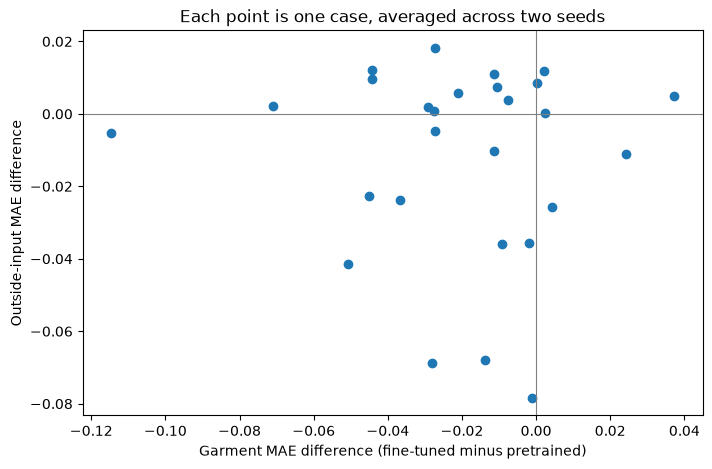

In [4]:
import matplotlib.pyplot as plt
means = recomputed['case_means']
ids = recomputed['complete_cases']
x = [means[i]['adapted-1000']['garment_mae'] - means[i]['pretrained']['garment_mae'] for i in ids]
y = [means[i]['adapted-1000']['outside_mae_input'] - means[i]['pretrained']['outside_mae_input'] for i in ids]
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(x,y)
ax.axhline(0,color='gray',linewidth=.8); ax.axvline(0,color='gray',linewidth=.8)
ax.set(xlabel='Garment MAE difference (fine-tuned minus pretrained)', ylabel='Outside-input MAE difference', title='Each point is one case, averaged across two seeds')
plt.show()

## How I read these results
A lower average error can hide poor individual examples. A model could also keep the input unchanged and score well on preservation while failing to change the clothing. I therefore read the preservation and garment results together.

Safety exclusions remain in the record, and leaving incomplete cases out of the paired summary can affect the findings. The bootstrap intervals describe uncertainty across the recorded test cases. They don't tell us how much results would vary across training runs or a different population.

The website uses the same attention checkpoint with a different resolution and number of steps. The offline gallery contains all final-test outputs. I didn't collect survey responses or human quality ratings.